Powerlifting Cohort Shift - Class Succession at Major Meets

William Le - 06/07/2026

The sharpest version of the thesis is about age of arrival at the top, not population averages. The question is whether lifters are reaching the best total in their weight class, at the meets that decide who is best, at junior and sub-junior ages, before the conventional peak window of the mid-20s and up.

This notebook restricts to major meets (World Classic Championships, Sheffield, US Open and Raw Nationals, European Classic Championships, and Age Division Nationals) and tracks the top total in each weight class each year with the lifter's age. The result is a succession lineage per class: who held the class, how old they were, and when a younger lifter took over.

A data note that matters here: Sheffield and some invitational meets record bodyweight but not weight class, so those rows have a missing WeightClassKg. The feature pipeline reconstructs the class from bodyweight before this analysis runs. Without that step every Sheffield performance is silently dropped from the per-class succession, which removes some of the strongest lifters in the sport (Perkins, Olivares, Sitko) from their own classes.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from powerlifting_cohort.features import add_features, dedupe_lifter_meets

Matplotlib is building the font cache; this may take a moment.


Prep, then build the major-meet filter. add_features reconstructs missing weight classes from bodyweight, so Sheffield performances are correctly assigned to their class.

In [2]:
df = pd.read_pickle("../data/processed/openipf_scoped.pkl")
df = add_features(df)
df = df[df["is_ipf_class"]]
df = dedupe_lifter_meets(df)
df["Date"] = pd.to_datetime(df["Date"])
df = df.dropna(subset=["TotalKg", "Age", "WeightClassKg"])

mn = df["MeetName"].fillna("")
worlds    = mn.str.contains("World Classic Powerlifting Championships", case=False, na=False)
sheffield = mn.str.contains("Sheffield", case=False, na=False)
open_nats = mn.str.contains(r"\bOpen Nationals\b|Classic Open Nationals", case=False, na=False, regex=True)
raw_nats  = mn.str.contains("Raw Nationals", case=False, na=False) & (df["Federation"] == "USAPL")
euros     = mn.str.contains("European Classic Powerlifting Championships|European Open Classic", case=False, na=False, regex=True)
adn       = mn.str.contains("Age Division Nationals", case=False, na=False)

df["is_major"] = worlds | sheffield | open_nats | raw_nats | euros | adn
maj = df[df["is_major"]].copy()
maj["Year"] = maj["Date"].dt.year

print(f"{len(maj):,} major-meet performances")
print(f"Sheffield rows retained: {(maj['MeetName'].str.contains('Sheffield', case=False, na=False)).sum()}")

16,387 major-meet performances
Sheffield rows retained: 88


The class kingpin each year: the lifter with the top total in each weight class at any major meet that year.

In [3]:
classes_m = ["59","66","74","83","93","105","120","120+"]
classes_f = ["47","52","57","63","69","76","84","84+"]

def kingpins(maj, sex, classes):
  rows = []
  for yr in range(2014, 2027):
    sub = maj[(maj["Sex"]==sex) & (maj["Year"]==yr)]
    for wc in classes:
      c = sub[sub["WeightClassKg"]==wc]
      if len(c)==0: continue
      t = c.nlargest(1, "TotalKg").iloc[0]
      rows.append({"Year": yr, "Class": wc, "Age": t["Age"],
                   "age_category": t["age_category"], "Total": t["TotalKg"],
                   "Name": t["Name"]})
  return pd.DataFrame(rows)

kp_m = kingpins(maj, "M", classes_m)
kp_f = kingpins(maj, "F", classes_f)
print(f"Men kingpin-years: {len(kp_m)}, Women: {len(kp_f)}")

Men kingpin-years: 96, Women: 84


Pooled kingpin age over time: the median age of the class kingpins across all classes each year. The line breaks at 2020 (COVID cancelled the major meets) and 2026 is a partial season through late May.

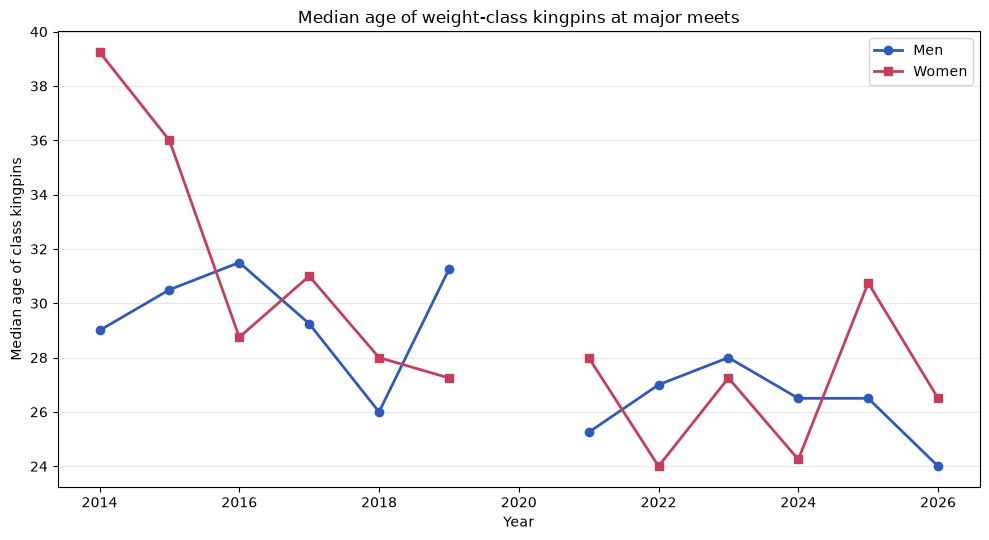

In [4]:
def pooled_age(kp):
  rows = []
  for yr, g in kp.groupby("Year"):
    if len(g) >= 4:
      rows.append({"Year": yr, "median_age": g["Age"].median(),
                   "mean_age": g["Age"].mean(), "n": len(g)})
  return pd.DataFrame(rows)

pa_m = pooled_age(kp_m)
pa_f = pooled_age(kp_f)

fig, ax = plt.subplots(figsize=(10, 5.5))
for pa, color, marker, label in [(pa_m,"#2E5BBA","o","Men"), (pa_f,"#C73E5C","s","Women")]:
  pre = pa[pa["Year"] <= 2019]
  post = pa[pa["Year"] >= 2021]
  ax.plot(pre["Year"], pre["median_age"], marker+"-", color=color, linewidth=2, label=label)
  ax.plot(post["Year"], post["median_age"], marker+"-", color=color, linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Median age of class kingpins")
ax.set_title("Median age of weight-class kingpins at major meets")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/05_kingpin_age.png", dpi=150, bbox_inches="tight")
plt.show()

Per-class succession tables, men. Age category in brackets: SJ = Sub-Junior (under 19), Jun = Junior (19-23), Ope = Open (24+), Mas = Masters (40+).

In [5]:
def print_succession(kp, classes):
  cat_abbr = {"Junior":"Jun", "SubJunior":"SJ", "Open":"Ope", "Masters":"Mas", "Youth":"Yth"}
  for wc in classes:
    sub = kp[kp["Class"]==wc].sort_values("Year")
    if len(sub)==0: continue
    print(f"=== {wc}kg ===")
    for _, r in sub.iterrows():
      cat = cat_abbr.get(r["age_category"], r["age_category"][:3])
      print(f"  {int(r['Year'])}: {r['Total']:6.1f}kg  age {r['Age']:>4.1f} [{cat}]  {r['Name']}")
    print()

print_succession(kp_m, classes_m)

=== 59kg ===
  2014:  661.0kg  age 31.0 [Ope]  Sergey Fedosienko
  2015:  656.0kg  age 32.0 [Ope]  Sergey Fedosienko
  2016:  669.5kg  age 33.0 [Ope]  Sergey Fedosienko
  2017:  660.0kg  age 34.0 [Ope]  Sergey Fedosienko
  2018:  664.0kg  age 35.0 [Ope]  Sergey Fedosienko
  2019:  635.0kg  age 36.0 [Ope]  Sergey Fedosienko
  2021:  640.0kg  age 39.0 [Ope]  Sergey Fedosienko
  2022:  585.0kg  age 27.0 [Ope]  Antoine Garcia
  2023:  625.0kg  age 25.5 [Ope]  Wascar Carpio
  2024:  638.0kg  age 26.0 [Ope]  Wascar Carpio
  2025:  638.0kg  age 27.0 [Ope]  Wascar Carpio
  2026:  670.0kg  age 16.0 [SJ]  Justin Nguyen #1

=== 66kg ===
  2014:  642.5kg  age 43.5 [Mas]  Mikhail Andryukhin
  2015:  650.5kg  age 36.5 [Ope]  Antti Savolainen
  2016:  670.0kg  age 26.5 [Ope]  Sergey Gladkikh
  2017:  680.0kg  age 27.5 [Ope]  Sergey Gladkikh
  2018:  688.0kg  age 22.5 [Jun]  Charles Okpoko
  2019:  705.5kg  age 23.5 [Jun]  Charles Okpoko
  2021:  702.5kg  age 24.0 [Ope]  Daniel Clements
  2022:  710.0

Per-class succession tables, women.

In [6]:
print_succession(kp_f, classes_f)

=== 47kg ===
  2014:  346.0kg  age 43.5 [Mas]  Olga Golubeva
  2015:  407.5kg  age 33.0 [Ope]  Wei-Ling Chen
  2016:  369.5kg  age 25.0 [Ope]  Heather Connor
  2017:  372.5kg  age 26.0 [Ope]  Heather Connor
  2018:  375.0kg  age 27.0 [Ope]  Heather Connor
  2019:  393.0kg  age 28.0 [Ope]  Heather Connor
  2021:  408.0kg  age 30.0 [Ope]  Heather Connor
  2022:  426.5kg  age 20.5 [Jun]  Tiffany Chapon
  2023:  428.5kg  age 21.5 [Jun]  Tiffany Chapon
  2024:  433.0kg  age 22.5 [Jun]  Tiffany Chapon
  2025:  435.0kg  age 34.0 [Ope]  Heather Connor
  2026:  451.5kg  age 24.0 [Ope]  Tiffany Chapon

=== 52kg ===
  2014:  385.0kg  age 23.5 [Jun]  Sofia Loft
  2015:  412.5kg  age 24.5 [Ope]  Sofia Loft
  2016:  417.5kg  age 25.5 [Ope]  Sofia Loft
  2017:  425.0kg  age 46.5 [Mas]  Olga Golubeva
  2018:  430.5kg  age 25.5 [Ope]  Joy Nnamani
  2019:  432.5kg  age 26.5 [Ope]  Joy Nnamani
  2021:  436.0kg  age 31.0 [Ope]  Noémie Allabert
  2022:  438.0kg  age 31.5 [Ope]  Noémie Allabert
  2023:  460

The "would this have won then" check. For a recent junior or sub-junior standout, compare their total against the best major-meet total in the same class in every prior year. This frames the young totals against the history of the class, which is the valid comparison. It deliberately does not rank these lifters against current peers, because recorded totals reflect best successful attempt, not maximum capacity, and a lifter managing a meet on conservative attempts posts a lower number than their ceiling.

In [7]:
def would_have_won(maj, sex, wc, total, label):
  print(f"{label}: {total:.1f}kg at {wc}kg")
  for yr in range(2014, 2027):
    sub = maj[(maj["Sex"]==sex) & (maj["WeightClassKg"]==wc) & (maj["Year"]==yr)]
    if len(sub)==0: continue
    best = sub["TotalKg"].max()
    mark = "beats" if total > best else "loses to"
    print(f"    {yr}: class best {best:6.1f}  ({mark})")

would_have_won(maj, "M", "59", 670.0, "Justin Nguyen (age 16, sub-junior, 2026)")
print()
would_have_won(maj, "M", "83", 900.0, "Joseph Borenstein (age 22, junior, 2025)")
print()
would_have_won(maj, "M", "93", 930.0, "William Ball (age 20, junior, 2026)")

Justin Nguyen (age 16, sub-junior, 2026): 670.0kg at 59kg
    2014: class best  661.0  (beats)
    2015: class best  656.0  (beats)
    2016: class best  669.5  (beats)
    2017: class best  660.0  (beats)
    2018: class best  664.0  (beats)
    2019: class best  635.0  (beats)
    2021: class best  640.0  (beats)
    2022: class best  585.0  (beats)
    2023: class best  625.0  (beats)
    2024: class best  638.0  (beats)
    2025: class best  638.0  (beats)
    2026: class best  670.0  (loses to)

Joseph Borenstein (age 22, junior, 2025): 900.0kg at 83kg
    2014: class best  770.5  (beats)
    2015: class best  787.5  (beats)
    2016: class best  813.0  (beats)
    2017: class best  795.0  (beats)
    2018: class best  830.5  (beats)
    2019: class best  833.0  (beats)
    2021: class best  843.0  (beats)
    2022: class best  810.0  (beats)
    2023: class best  835.0  (beats)
    2024: class best  860.0  (beats)
    2025: class best  900.0  (loses to)
    2026: class best  892.

Summary.

The genuine junior and sub-junior takeovers are at 59, 66, 83, and 93 kg. At 59kg, Sergey Fedosienko held the class from 2014 to 2021, aging from 31 to 39, with a peak of 669.5kg; in 2026 a sixteen-year-old sub-junior, Justin Nguyen, posted 670kg, exceeding the entire reign. At 83kg, Joseph Borenstein took the class at 22 in 2025 with 900kg, the highest total in the lineage. At 93kg, after Jonathan Cayco held the class from age 26 to 32, William Ball took it at 20 in 2026 with 930kg. At 66kg, Austin Nikolai took it at 22 in 2026. In each case the total is not strong-for-age; it is the best the class has seen, posted before the conventional peak window.

74kg is a different and important case. It is not a junior takeover. Austin Perkins has held the class since 2024 and posted 891.5kg at Sheffield in 2026 at age 26, the highest 74kg total on record. Perkins reached the top at 24 as an Open lifter, on the conventional timeline, and is still rising. He is the benchmark of what reaching the top normally looks like, and his presence is what makes the junior arrivals legible: Elliott Sykes posting 852.5kg at 19 is remarkable because it clears the open-class history of the class, not because it surpasses Perkins, who is the better lifter. Perkins's 891.5 came on conservative attempts, so his true ceiling is higher than the recorded figure.

The two heaviest classes are the honest exception. At 105, 120, and 120+ kg the top totals belong to lifters in their mid-to-late 20s. Jesus Olivares at 120+ is a distinct pattern: he took the class as a junior at 22 in 2021 and has held it since, a young arrival that aged into a long reign rather than a recent handoff. Heavyweight powerlifting has long peaked later, which is consistent with the slower change in these classes.

The women's kingpin age shows no trend. Outside of Agata Sitko, the women posting the top totals in their classes at major meets remain in their mid-20s to 30s. The cohort shift visible in the women's median-age and peak-age analyses does not reach within-class dominance at the major meets.

For context, notable junior totals at the Junior and Sub-Junior European Championships, which are excluded from the succession filter because every lifter there is junior-age by definition: Malik Bernoussi Triolet posted 840kg at 93kg at age 21, Manson Adagu 817.5kg at 83kg at 23, and Zuzanna Mazur 586.5kg at 76kg at 19. These are totals that would have placed at the senior level in their classes in the recent past.